In [57]:
import matplotlib.pyplot as plt
import fss_SAT
import numpy as np
import matplotlib as mpl

In [2]:
obs_A = np.array([
    [0, 0, 1, 0, 0],
    [1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1],
    [0, 1, 0, 0, 0]])

mod_A = np.array([
    [0, 1, 0, 0, 1],
    [0, 0, 0, 0, 0],
    [1, 0, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0]])

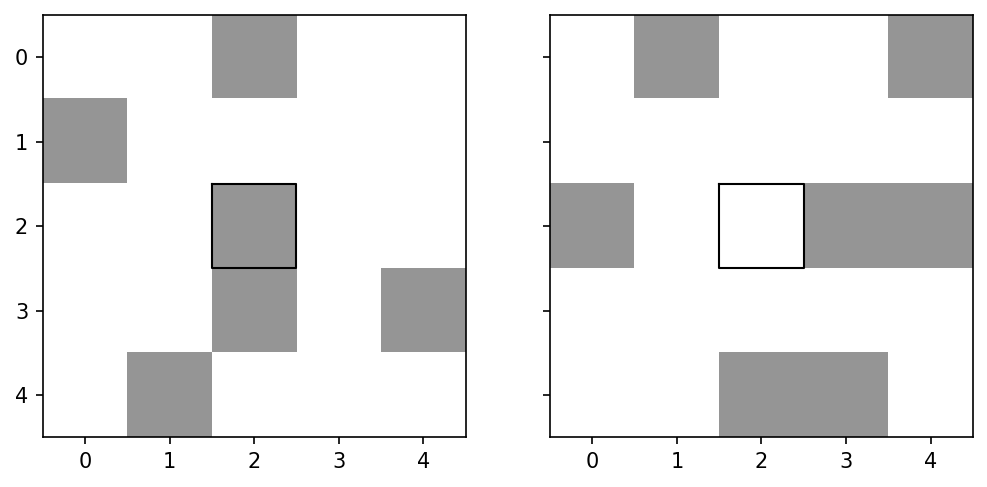

In [144]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=150, sharex=True, sharey=True)
ax[0].imshow(obs_A, cmap="Grays", vmin=0, vmax=2.)
ax[1].imshow(mod_A, cmap="Grays", vmin=0, vmax=2.)
ax[0].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1)
ax[1].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1)
#ax[0].set_xticks([])
#ax[0].set_yticks([])

In [160]:
mask1 = np.array([
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]])

mask2 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0]])

obs_B = np.where(mask1 == 1, np.nan, obs_A)
obs_C = np.where(mask2 == 1, np.nan, obs_A)

mod_B = np.where(mask1 == 1, np.nan, mod_A)
mod_C = np.where(mask2 == 1, np.nan, mod_A)

In [161]:
def mark_missing(ax, mask):
    nx, ny = mask.shape
    for ii in range(mask.shape[0]):
        for jj in range(mask.shape[1]):
            if mask[nx - jj - 1, ny - ii - 1] == 1:
                ax.plot([ny - ii - 1-0.45, ny - ii - 1+0.45], [nx - jj - 1-0.45, nx - jj - 1+0.45], 'k', lw=0.75)
                ax.plot([ny - ii - 1-0.45, ny - ii - 1+0.45], [nx - jj - 1+0.45, nx - jj - 1-0.45], 'k', lw=0.75)
            else:
                ax.plot([ny - ii - 1-0.15, ny - ii - 1+0.15], [nx - jj - 1, nx - jj - 1], 'k', lw=0.75)
                ax.plot([ny - ii - 1, ny - ii - 1], [nx - jj - 1+0.15, nx - jj - 1-0.15], 'k', lw=0.75)
                



Text(1.5, 5.0, '$\\bf{NaN}$, $\\frac{\\bf{5}}{\\bf{21}}$')

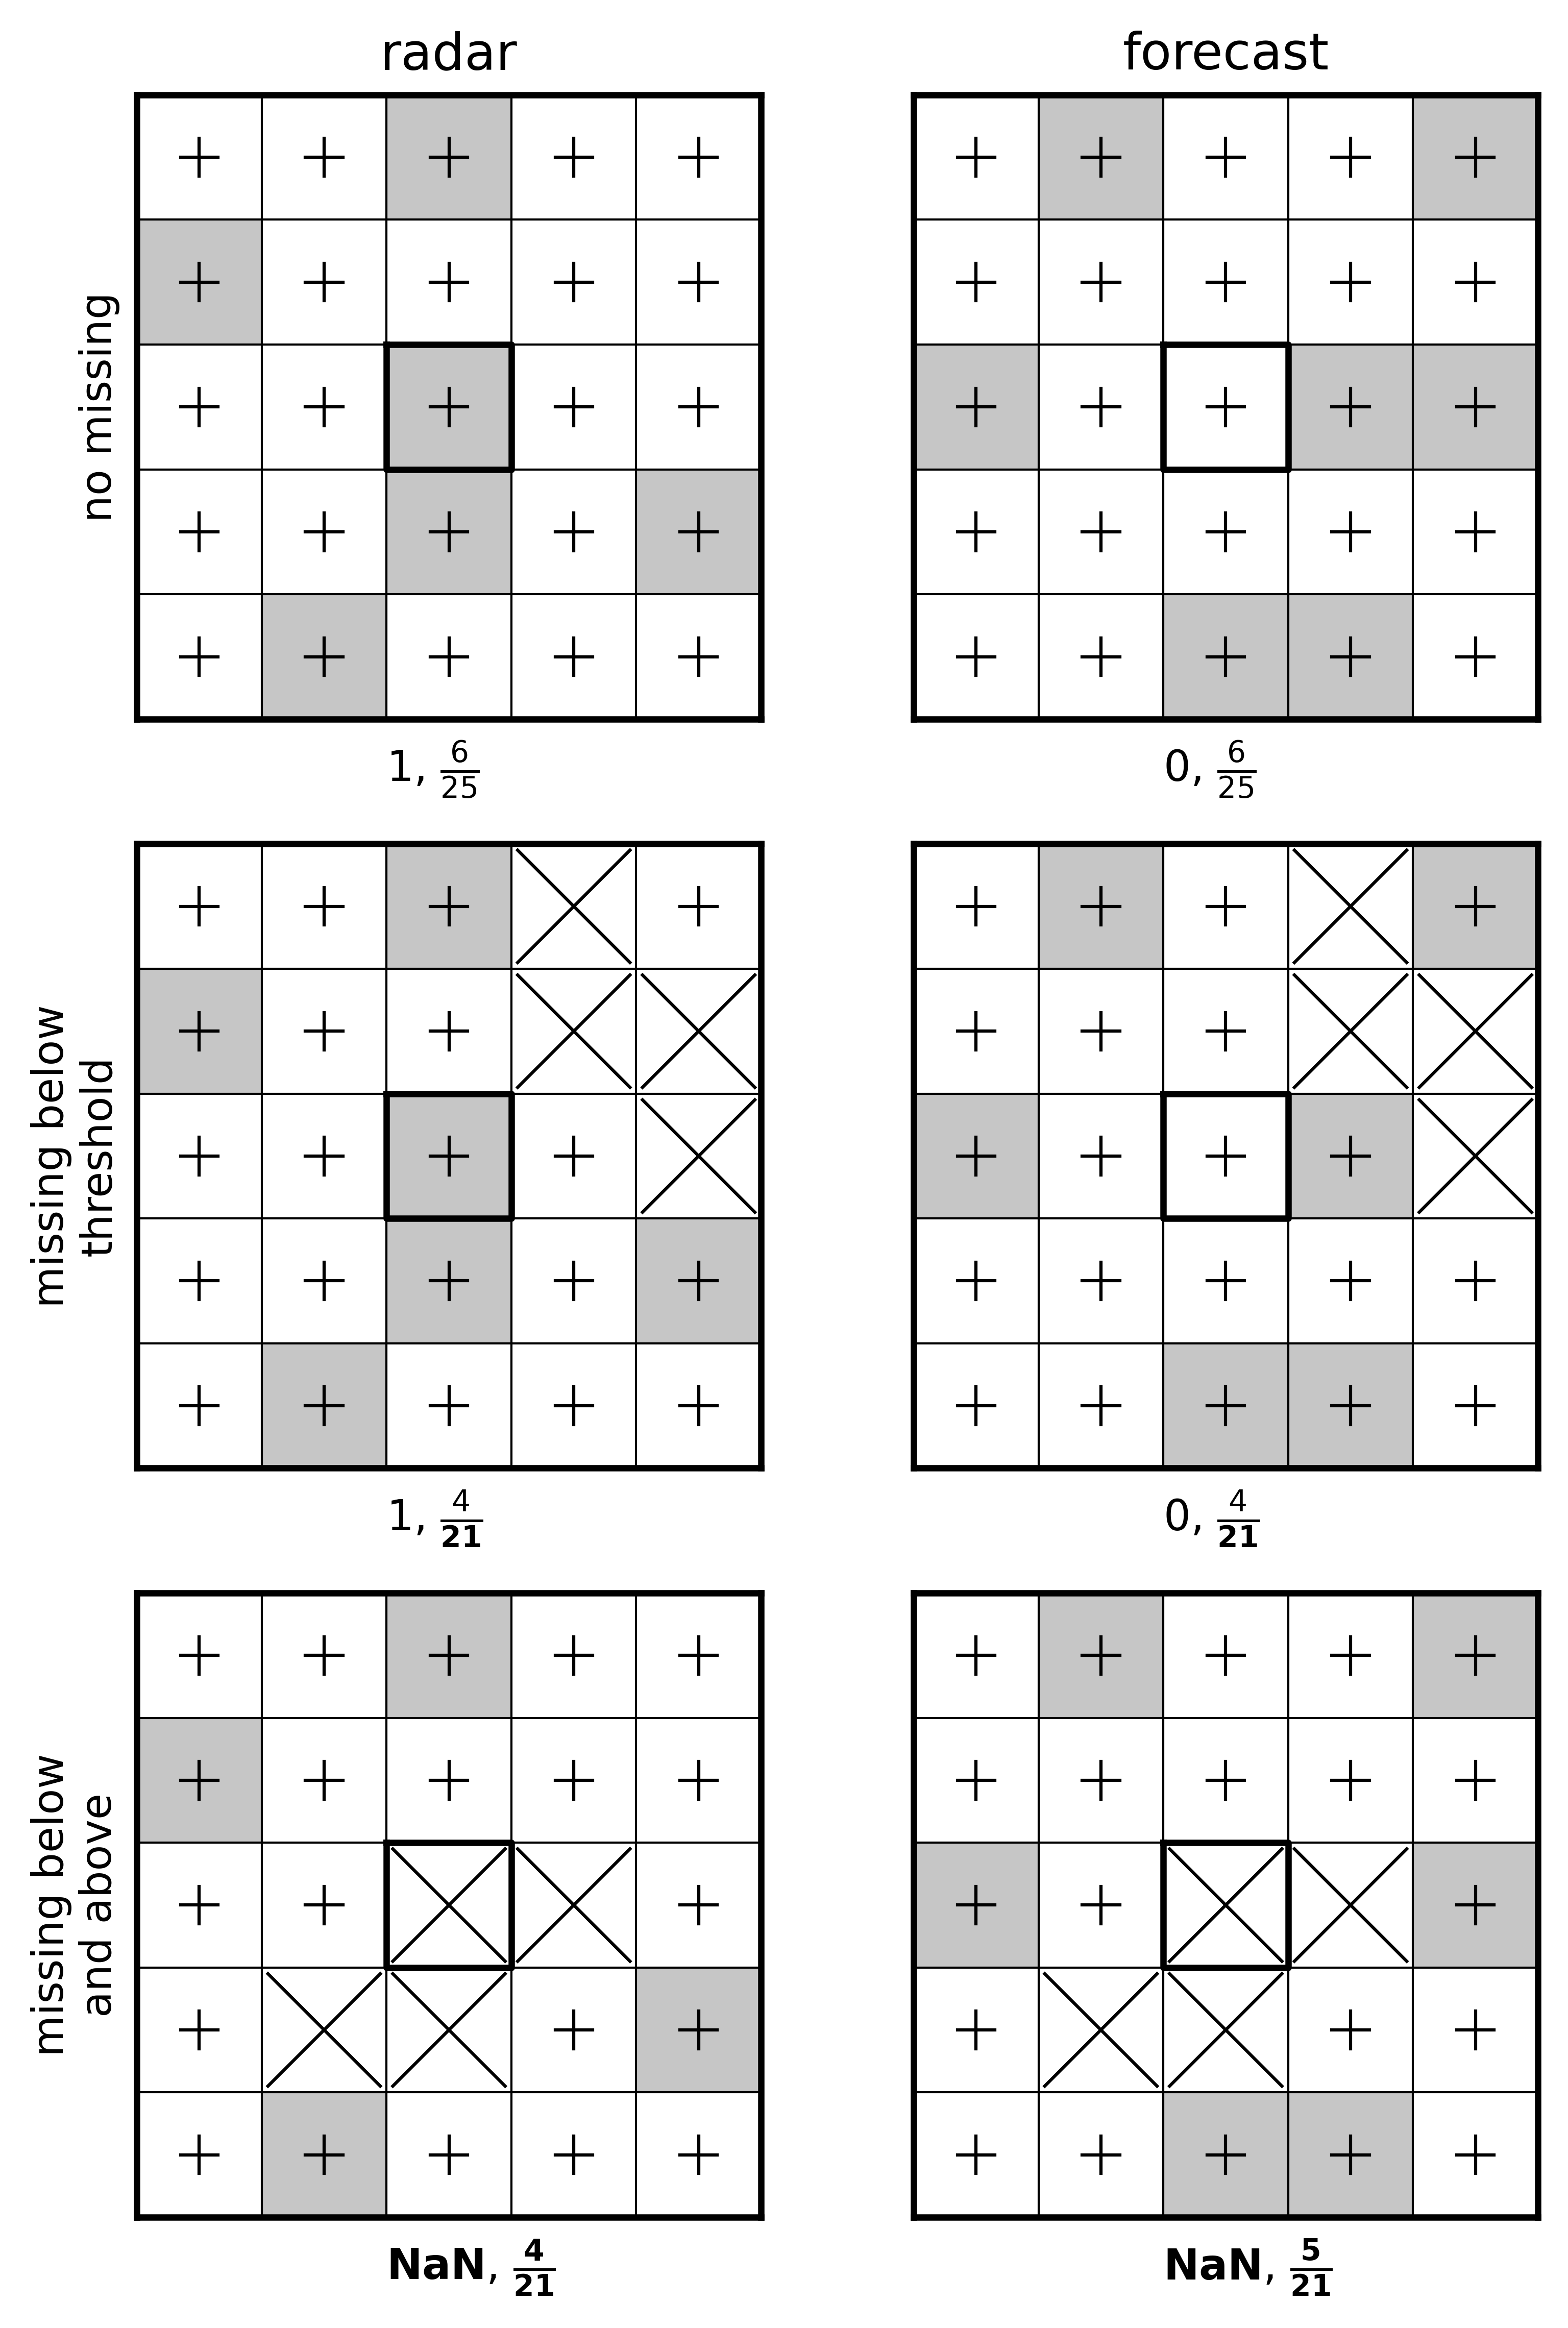

In [175]:
cmap = mpl.colormaps["Grays"]
# cmap.set_bad("Lightgray")

fig, ax = plt.subplots(3, 2, figsize=(6, 9), dpi=600, sharex=True, sharey=True)
ax[0][0].imshow(obs_A, cmap=cmap, vmin=0, vmax=3.)
ax[0][1].imshow(mod_A, cmap=cmap, vmin=0, vmax=3.)
mark_missing(ax[0][0], np.zeros((5, 5)))
mark_missing(ax[0][1], np.zeros((5, 5)))

ax[1][0].imshow(obs_B, cmap=cmap, vmin=0, vmax=3.)
ax[1][1].imshow(mod_B, cmap=cmap, vmin=0, vmax=3.)
# Hatch only masked cells
mark_missing(ax[1][0], mask1)
mark_missing(ax[1][1], mask1)
mark_missing(ax[2][0], mask2)
mark_missing(ax[2][1], mask2)


ax[2][0].imshow(obs_C, cmap=cmap, vmin=0, vmax=3.)
ax[2][1].imshow(mod_C, cmap=cmap, vmin=0, vmax=3.)

ax[0][0].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1.5)
ax[0][1].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1.5)

ax[1][0].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1.5)
ax[1][1].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1.5)

ax[2][0].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1.5)
ax[2][1].plot([1.5, 2.5, 2.5, 1.5, 1.5], [1.5, 1.5, 2.5, 2.5, 1.5], 'k', lw=1.5)

ax[0][0].set_xticks(np.arange(-0.5, 4.51, 1.))
ax[0][0].set_yticks(np.arange(-0.5, 4.51, 1.))
#ax[0][0].set_yticks([])

fracs1 = r"1, $\frac{6}{25}$"
fracs2 = r"0, $\frac{6}{25}$"
fracs3 = r"1, $\frac{4}{\bf{21}}$"
fracs4 = r"0, $\frac{4}{\bf{21}}$"
fracs5 = r"$\bf{NaN}$, $\frac{\bf{4}}{\bf{21}}$"
fracs6 = r"$\bf{NaN}$, $\frac{\bf{5}}{\bf{21}}$"

ax[0][0].set_title("radar")
ax[0][1].set_title("forecast")

#ax[1][0].set_title(f"Missing only below the threshold\nc) radar {fracs2}", loc="left")
#ax[1][1].set_title(f"d) forecast {fracs2}", loc="left")

#ax[2][0].set_title(f"Missing above and below threshold\ne) radar {fracs3}", loc="left")
#ax[2][1].set_title(f"f) forecast {fracs4}", loc="left")


for ax_ in ax.flatten():
    ax_.grid(linewidth=0.5, color='k')
    ax_.tick_params(
        axis='both',
        which='both',
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False
    )
    ax_.spines['left'].set_linewidth(1.5)
    ax_.spines['right'].set_linewidth(1.5)
    ax_.spines['top'].set_linewidth(1.5)
    ax_.spines['bottom'].set_linewidth(1.5)

ax[0][0].set_ylabel("no missing")
ax[1][0].set_ylabel("missing below\nthreshold")
ax[2][0].set_ylabel("missing below\nand above")

ax[0][0].text(1.5, 5., fracs1)
ax[0][1].text(1.5, 5., fracs2)
ax[1][0].text(1.5, 5., fracs3)
ax[1][1].text(1.5, 5., fracs4)
ax[2][0].text(1.5, 5., fracs5)
ax[2][1].text(1.5, 5., fracs6)


In [170]:
### Do some validation
obs_A, mod_A
obs_cache = fss_SAT.compute_integral_table(obs_B)
mod_cache = fss_SAT.compute_integral_table(mod_B)
bad_cache = fss_SAT.compute_integral_table(mask1)

In [171]:
obs_cache, mod_cache, bad_cache

(array([[ 0.,  0.,  1., nan, nan],
        [ 1.,  1.,  2., nan, nan],
        [ 1.,  1.,  3., nan, nan],
        [ 1.,  1.,  4., nan, nan],
        [ 1.,  2.,  5., nan, nan]]),
 array([[ 0.,  1.,  1., nan, nan],
        [ 0.,  1.,  1., nan, nan],
        [ 1.,  2.,  2., nan, nan],
        [ 1.,  2.,  2., nan, nan],
        [ 1.,  2.,  3., nan, nan]]),
 array([[0, 0, 0, 1, 1],
        [0, 0, 0, 2, 3],
        [0, 0, 0, 2, 4],
        [0, 0, 0, 2, 4],
        [0, 0, 0, 2, 4]]))

In [173]:
mod_B

array([[ 0.,  1.,  0., nan,  1.],
       [ 0.,  0.,  0., nan, nan],
       [ 1.,  0.,  0.,  1., nan],
       [ 0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  1.,  0.]])